###**Renewable Energy Dataset - K-Means Clustering**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("complete_renewable_energy_dataset_missing.csv")

df.head()

,Country,Year,Energy Type,Production (GWh),Installed Capacity (MW),Investments (USD),Population,GDP,Energy Consumption,Energy Exports,...,Economic Freedom Index,Ease of Doing Business,Innovation Index,Number of Research Institutions,Number of Renewable Energy Conferences,Number of Renewable Energy Publications,Energy Sector Workforce,Proportion of Energy from Renewables,Public-Private Partnerships in Energy,Regional Renewable Energy Cooperation
0,USA,2011,Solar,85404.69003,5549.794323,5.604125e+09,1.064007e+09,1.780000e+14,369654.6442,93087.198200,...,49.216800,57.678605,76.803228,851,75,6361,511658,25.907895,1,0
1,Australia,2008,Geothermal,22205.06938,43211.593800,6.361886e+08,1.033256e+09,6.440000e+13,771781.6363,1752.536054,...,79.990942,1.761579,48.697825,590,39,9752,974948,95.003547,0,1
2,Canada,2013,Biomass,NaN,6139.117212,6.158680e+09,1.489512e+07,1.570000e+14,342707.1529,65146.592500,...,94.374040,77.657334,67.334813,101,7,311,326318,67.354539,1,0
3,Japan,2010,Biomass,88771.93291,40323.639260,8.526116e+09,1.448827e+09,1.350000e+14,498839.5743,50257.591010,...,65.143472,44.987734,4.544289,327,3,7708,506078,33.754104,0,0
4,China,2018,Solar,93288.40858,30755.403060,5.086237e+09,1.499494e+09,8.680000e+13,819064.3628,63101.395560,...,86.213626,62.535223,10.287199,985,69,4919,187964,59.509228,1,0


In [3]:
print(df.shape)

(2500, 56)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 56 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Country                                  2500 non-null   object 
 1   Year                                     2500 non-null   int64  
 2   Energy Type                              2498 non-null   object 
 3   Production (GWh)                         2499 non-null   float64
 4   Installed Capacity (MW)                  2500 non-null   float64
 5   Investments (USD)                        2500 non-null   float64
 6   Population                               2499 non-null   float64
 7   GDP                                      2500 non-null   float64
 8   Energy Consumption                       2500 non-null   float64
 9   Energy Exports                           2500 non-null   float64
 10  Energy Imports                           2500 no

In [5]:
df.describe()

,Year,Production (GWh),Installed Capacity (MW),Investments (USD),Population,GDP,Energy Consumption,Energy Exports,Energy Imports,CO2 Emissions,...,Economic Freedom Index,Ease of Doing Business,Innovation Index,Number of Research Institutions,Number of Renewable Energy Conferences,Number of Renewable Energy Publications,Energy Sector Workforce,Proportion of Energy from Renewables,Public-Private Partnerships in Energy,Regional Renewable Energy Cooperation
count,2500.000000,2499.000000,2500.000000,2.500000e+03,2.499000e+03,2.500000e+03,2500.000000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000
mean,2011.437600,48725.043998,24882.910674,4.956155e+09,7.460187e+08,1.010717e+14,495701.245158,50143.392627,50800.373871,491218.412643,...,50.736720,48.442085,50.280019,496.660400,50.431200,4978.93360,502040.891200,49.749110,0.512000,0.473600
std,6.895471,28332.049485,14463.459958,2.894789e+09,4.373568e+08,5.782829e+13,291419.017956,28833.333066,28740.851763,289783.733338,...,28.623766,28.798216,28.719483,296.181011,28.877168,2881.93256,293084.636148,28.924307,0.499956,0.499402
min,2000.000000,1053.354158,114.531639,5.886994e+06,1.255357e+06,5.603965e+10,1264.851083,1036.618008,1057.783513,1124.768458,...,0.104915,0.025281,0.025733,0.000000,0.000000,3.00000,494.000000,0.033829,0.000000,0.000000
25%,2006.000000,24307.893805,12282.213158,2.473145e+09,3.719678e+08,5.050000e+13,237300.546575,25146.745295,26347.461048,242894.720500,...,26.241437,23.519814,25.934406,234.000000,26.000000,2532.00000,244438.000000,23.968451,0.000000,0.000000
50%,2011.000000,47341.460670,24689.162460,4.961772e+09,7.517937e+08,1.030000e+14,496118.165250,49706.656935,50698.800025,475721.007850,...,50.850766,48.127673,51.398964,493.000000,51.000000,4992.50000,499151.000000,50.232069,1.000000,0.000000
75%,2017.250000,73028.524390,37438.443573,7.418384e+09,1.118071e+09,1.520000e+14,753779.282800,75567.191518,75807.642497,747649.446325,...,74.908485,73.324825,74.724073,755.000000,76.000000,7465.00000,765088.000000,74.354781,1.000000,1.000000
max,2023.000000,99937.503720,49997.387580,9.998292e+09,1.499494e+09,2.000000e+14,999618.512200,99952.509820,99912.213810,999816.500200,...,99.970526,99.901347,99.998838,999.000000,99.000000,9999.00000,999226.000000,99.988355,1.000000,1.000000


In [6]:
df.isnull().sum()

,0
Country,0
Year,0
Energy Type,2
Production (GWh),1
Installed Capacity (MW),0
Investments (USD),0
Population,1
GDP,0
Energy Consumption,0
Energy Exports,0


In [7]:
# Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Categorical Columns
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values Handled Successfully")

Missing Values Handled Successfully


Missing numerical values were replaced using the mean, while categorical values were replaced using the mode to preserve the dataset.

In [8]:
print(df.columns)

Index(['Country', 'Year', 'Energy Type', 'Production (GWh)',
       'Installed Capacity (MW)', 'Investments (USD)', 'Population', 'GDP',
       'Energy Consumption', 'Energy Exports', 'Energy Imports',
       'CO2 Emissions', 'Renewable Energy Jobs', 'Government Policies',
       'R&D Expenditure', 'Renewable Energy Targets',
       'Average Annual Temperature', 'Annual Rainfall', 'Solar Irradiance',
       'Wind Speed', 'Hydro Potential', 'Geothermal Potential',
       'Biomass Availability', 'Energy Storage Capacity',
       'Grid Integration Capability', 'Electricity Prices', 'Energy Subsidies',
       'International Aid for Renewables', 'Public Awareness',
       'Energy Efficiency Programs', 'Urbanization Rate',
       'Industrialization Rate', 'Energy Market Liberalization',
       'Renewable Energy Patents', 'Educational Level',
       'Technology Transfer Agreements', 'Renewable Energy Education Programs',
       'Local Manufacturing Capacity', 'Import Tariffs on Energy Equipme

In [9]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,Year,Production (GWh),Installed Capacity (MW),Investments (USD),Population,GDP,Energy Consumption,Energy Exports,Energy Imports,CO2 Emissions,...,Economic Freedom Index,Ease of Doing Business,Innovation Index,Number of Research Institutions,Number of Renewable Energy Conferences,Number of Renewable Energy Publications,Energy Sector Workforce,Proportion of Energy from Renewables,Public-Private Partnerships in Energy,Regional Renewable Energy Cooperation
0,2011,85404.690030,5549.794323,5.604125e+09,1.064007e+09,1.780000e+14,369654.6442,93087.198200,13413.18474,294399.37790,...,49.216800,57.678605,76.803228,851,75,6361,511658,25.907895,1,0
1,2008,22205.069380,43211.593800,6.361886e+08,1.033256e+09,6.440000e+13,771781.6363,1752.536054,78493.98221,826531.67830,...,79.990942,1.761579,48.697825,590,39,9752,974948,95.003547,0,1
2,2013,48725.043998,6139.117212,6.158680e+09,1.489512e+07,1.570000e+14,342707.1529,65146.592500,41114.87219,43695.24019,...,94.374040,77.657334,67.334813,101,7,311,326318,67.354539,1,0
3,2010,88771.932910,40323.639260,8.526116e+09,1.448827e+09,1.350000e+14,498839.5743,50257.591010,42010.47594,840378.79670,...,65.143472,44.987734,4.544289,327,3,7708,506078,33.754104,0,0
4,2018,93288.408580,30755.403060,5.086237e+09,1.499494e+09,8.680000e+13,819064.3628,63101.395560,17912.96194,162034.25430,...,86.213626,62.535223,10.287199,985,69,4919,187964,59.509228,1,0


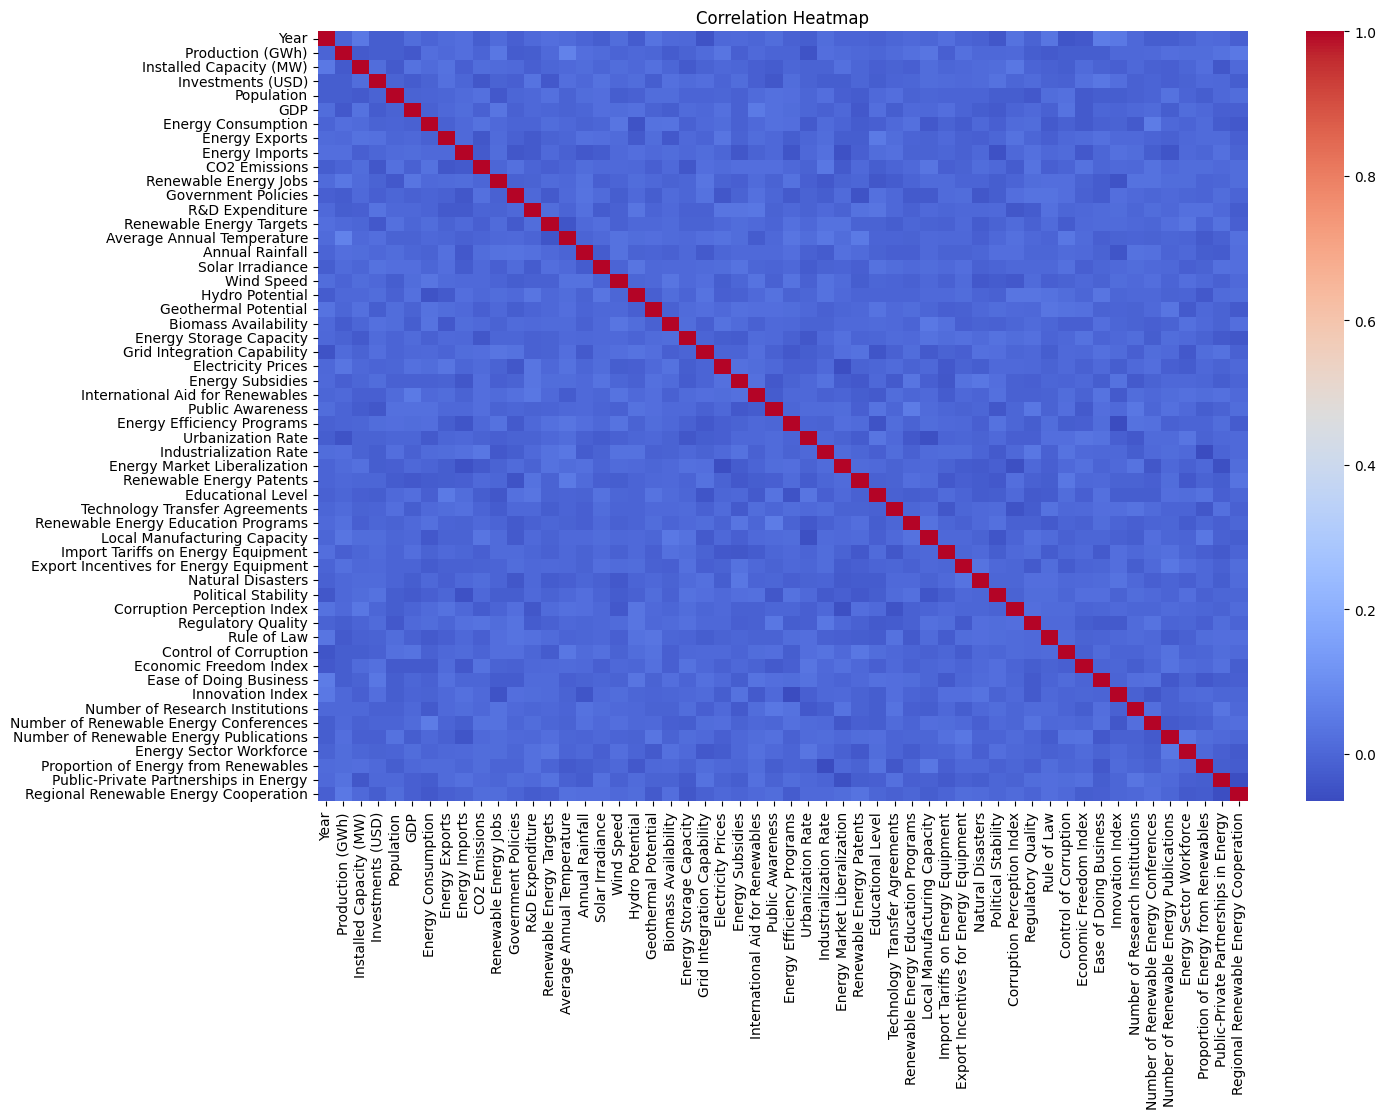

In [10]:
plt.figure(figsize=(15,10))

sns.heatmap(numeric_df.corr(),
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

The heatmap shows relationships among renewable energy indicators. Features with stronger correlations may belong to similar clusters.

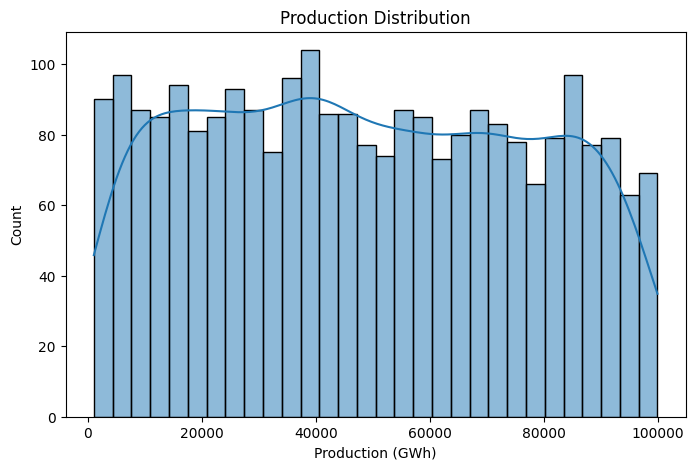

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Production (GWh)"], bins=30, kde=True)

plt.title("Production Distribution")

plt.show()

The distribution helps understand whether energy production is normally distributed or skewed.

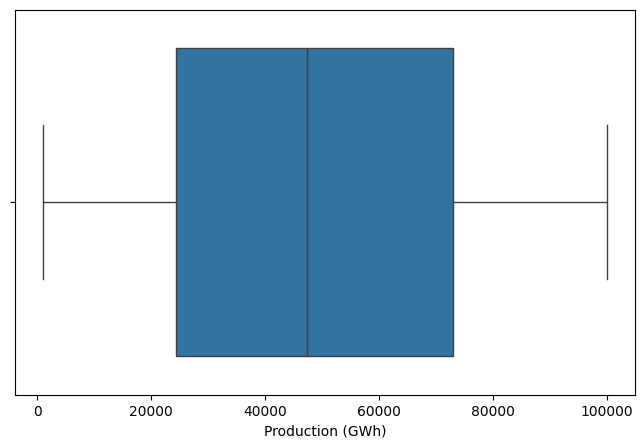

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Production (GWh)"])

plt.show()

The boxplot identifies outliers in renewable energy production.

In [13]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_df)

Scaling ensures that all numerical features contribute equally during clustering.

In [14]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10)

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

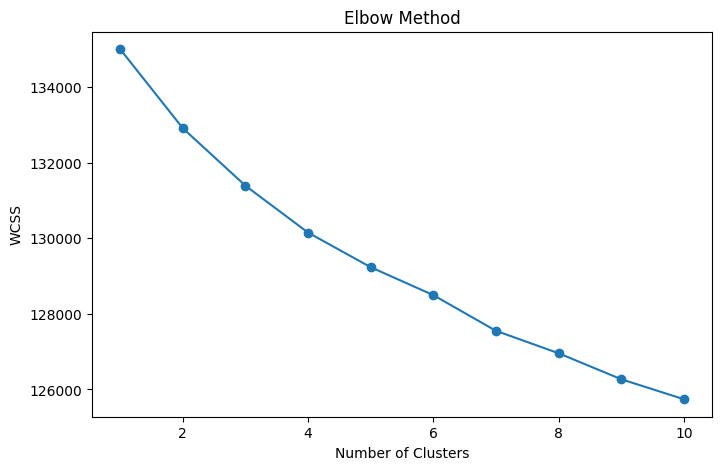

In [15]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

The optimal number of clusters is selected where the curve forms an "elbow", indicating diminishing improvement with additional clusters.

In [33]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

df.head()

,Country,Year,Energy Type,Production (GWh),Installed Capacity (MW),Investments (USD),Population,GDP,Energy Consumption,Energy Exports,...,Ease of Doing Business,Innovation Index,Number of Research Institutions,Number of Renewable Energy Conferences,Number of Renewable Energy Publications,Energy Sector Workforce,Proportion of Energy from Renewables,Public-Private Partnerships in Energy,Regional Renewable Energy Cooperation,Cluster
0,USA,2011,Solar,85404.690030,5549.794323,5.604125e+09,1.064007e+09,1.780000e+14,369654.6442,93087.198200,...,57.678605,76.803228,851,75,6361,511658,25.907895,1,0,7
1,Australia,2008,Geothermal,22205.069380,43211.593800,6.361886e+08,1.033256e+09,6.440000e+13,771781.6363,1752.536054,...,1.761579,48.697825,590,39,9752,974948,95.003547,0,1,3
2,Canada,2013,Biomass,48725.043998,6139.117212,6.158680e+09,1.489512e+07,1.570000e+14,342707.1529,65146.592500,...,77.657334,67.334813,101,7,311,326318,67.354539,1,0,7
3,Japan,2010,Biomass,88771.932910,40323.639260,8.526116e+09,1.448827e+09,1.350000e+14,498839.5743,50257.591010,...,44.987734,4.544289,327,3,7708,506078,33.754104,0,0,0
4,China,2018,Solar,93288.408580,30755.403060,5.086237e+09,1.499494e+09,8.680000e+13,819064.3628,63101.395560,...,62.535223,10.287199,985,69,4919,187964,59.509228,1,0,1


In [34]:
print(df["Cluster"].value_counts())

Cluster
3    284
7    263
4    259
1    253
2    247
9    246
8    245
5    240
0    235
6    228
Name: count, dtype: int64


In [35]:
score = silhouette_score(scaled_data, clusters)

print("Silhouette Score :", score)

Silhouette Score : 0.01393205076392726


A higher Silhouette Score indicates better-separated and more meaningful clusters. Values closer to 1 represent stronger clustering, while values near 0 indicate overlapping clusters.

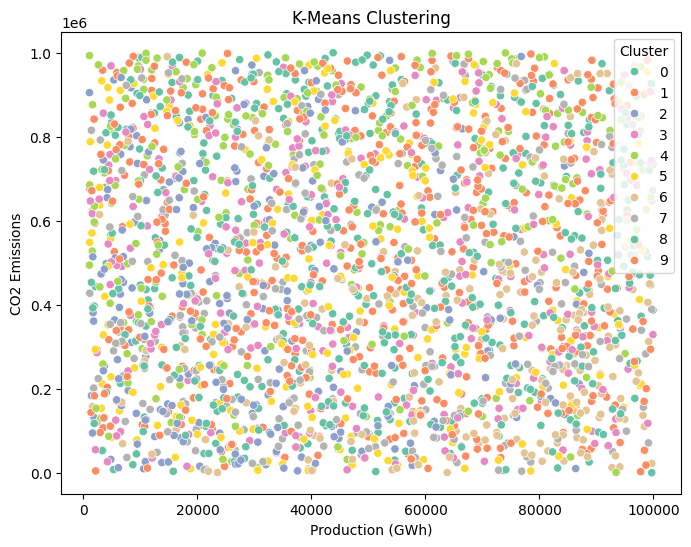

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production (GWh)",
    y="CO2 Emissions",
    hue="Cluster",
    palette="Set2"
)

plt.title("K-Means Clustering")

plt.show()

K-Means is an unsupervised machine learning algorithm used to group similar data points into clusters.

It is suitable for this project because:
- There is no target variable.
- It identifies hidden patterns in renewable energy data.
- It groups similar observations based on feature similarity.

The scatter plot visualizes how countries or records are grouped into different clusters based on renewable energy production and CO₂ emissions.

## Insights

- The dataset was cleaned by handling missing values.
- Numerical features were standardized before clustering.
- The Elbow Method was used to determine the optimal number of clusters.
- K-Means successfully grouped similar renewable energy records.
- The Silhouette Score was used to evaluate clustering quality.
- The clusters can help identify countries or regions with similar renewable
- energy characteristics, supporting sustainability planning and policy decisions.